# **Análisis de Señales de Electrocardiografía (ECG)**
---

En este Jupyter Notebook se detalla el procedimiento completo para el procesamiento y análisis de las señales de electrocardiografía (ECG) adquiridas con el dispositivo BITalino. El objetivo es transformar los datos crudos en métricas fisiológicas interpretables, como la Frecuencia Cardíaca (FC) y su variabilidad (HRV), para comparar diferentes estados fisiológicos: reposo, apnea y post-ejercicio.

El análisis se estructura en las siguientes fases:

1.  **Preparación y Procesamiento Fundamental:** Carga, filtrado y detección de picos R en todas las señales.
2.  **Análisis por Segmentos y Extracción de Métricas:** Aislamiento de los periodos de interés (apnea/normal) y cálculo de métricas clave en el dominio del tiempo (BPM, SDNN, RMSSD).
3.  **Análisis Comparativo y Avanzado:** Visualización de resultados, pruebas estadísticas, comparación morfológica entre derivaciones y análisis de clustering de los complejos QRS.

---
## **1: Preparación y Procesamiento Fundamental**
---

### **1. Configuración del Entorno y Funciones**

#### **1.1. Importación de Librerías**
Iniciamos importando las librerías de Python necesarias para el análisis numérico, la manipulación de datos, el procesamiento de señales y la visualización. Las librerías utilizadas así como el .yml necesario para todos los códigos del proyecto se unificarán en un solo archivo para poder facilitar la clonación del enviroment.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks, welch, resample
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
import warnings

# Configuración de estilo para los gráficos
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')
print("Librerías importadas")

Librerías importadas


#### **1.2. Configuración de Rutas y Archivos de Datos**
Definimos la ruta a la carpeta que contiene los datos. El sistema BITalino genera varios archivos por cada registro. Para este análisis, utilizaremos los archivos `_converted.txt`, que contienen los datos ya escalados a unidades físicas (Voltios), simplificando el paso de conversión. El siguiente código buscará y cargará automáticamente todos los archivos pertinentes.

In [2]:
# Ruta a la carpeta que contiene las señales
carpeta_datos = "../Señales_adquiridas_en_el_laboratorio"

# Parámetros de la adquisición
fs = 1000  # Frecuencia de muestreo en Hz

# Diccionario para almacenar los datos cargados (tiempo y señal)
datos_cargados = {}

# Verificar la carpeta 
if not os.path.isdir(carpeta_datos):
    print(f"Error: La carpeta '{carpeta_datos}' no fue encontrada.")
else:
    archivos_ecg = sorted([f for f in os.listdir(carpeta_datos) if f.endswith("_converted.txt")])
    print(f"Se encontraron {len(archivos_ecg)} archivos de ECG para analizar:")
    
    for archivo in archivos_ecg:
        print(f" - Cargando: {archivo}")
        ruta_completa = os.path.join(carpeta_datos, archivo)
        
        # Carga de datos
        try:
            with open(ruta_completa, 'r') as f:
                for i, linea in enumerate(f):
                    if "EndOfHeader" in linea:
                        skiprows = i + 1
                        break
                else: skiprows = 0
            
            df = pd.read_csv(ruta_completa, sep="\t", skiprows=skiprows, header=None)
            nombres_cols = ["nSeq", "I1", "I2", "O1", "O2", "A2", "A5"]
            df.columns = nombres_cols[:len(df.columns)]
            
            senal = df["A2"].values
            tiempo = np.arange(len(senal)) / fs
            datos_cargados[archivo] = {'tiempo': tiempo, 'senal_v': senal}
        except Exception as e:
            print(f"   -> Error al cargar el archivo: {e}")

if datos_cargados:
    print("\nCarga de datos completada.")

Se encontraron 4 archivos de ECG para analizar:
 - Cargando: Derivacion_1_reposo_2025-09-10_11-47-35_converted.txt
 - Cargando: Derivacion_2_reposo_2025-09-10_12-02-50_converted.txt
 - Cargando: derivacion_2_actividad_fisica_2025-09-10_12-24-06_converted.txt
 - Cargando: derivación_1_actividad_fisica_2025-09-10_12-20-25_converted.txt

Carga de datos completada.


In [3]:
# Verificación del diccionario de datos cargados
for nombre, datos in list(datos_cargados.items()):
    print(f"\nArchivo: {nombre}")
    print(f" - Duración: {datos['tiempo'][-1]:.2f} s")
    print(f" - Número de muestras: {len(datos['senal_v'])}")
    print(f" - Primeras 5 muestras de la señal: {datos['senal_v'][:5]}")


Archivo: Derivacion_1_reposo_2025-09-10_11-47-35_converted.txt
 - Duración: 269.70 s
 - Número de muestras: 269700
 - Primeras 5 muestras de la señal: [-0.053 -0.064 -0.073 -0.085 -0.091]

Archivo: Derivacion_2_reposo_2025-09-10_12-02-50_converted.txt
 - Duración: 270.45 s
 - Número de muestras: 270450
 - Primeras 5 muestras de la señal: [-0.404 -0.425 -0.445 -0.457 -0.466]

Archivo: derivacion_2_actividad_fisica_2025-09-10_12-24-06_converted.txt
 - Duración: 90.45 s
 - Número de muestras: 90450
 - Primeras 5 muestras de la señal: [-0.015 -0.012 -0.015 -0.023 -0.038]

Archivo: derivación_1_actividad_fisica_2025-09-10_12-20-25_converted.txt
 - Duración: 120.90 s
 - Número de muestras: 120900
 - Primeras 5 muestras de la señal: [0.1   0.105 0.108 0.111 0.105]


##### **Visualización del Efecto del Filtrado**
Antes de proceder con el análisis completo, es fundamental visualizar el impacto del preprocesamiento. A continuación, aplicamos el filtro pasa-banda a un segmento de 10 segundos de una señal en reposo y otra post-ejercicio para demostrar su eficacia. Los gráficos comparan la señal original (cruda) con la señal filtrada.

Se puede observar cómo el filtro:
1.  **Estabiliza la línea de base:** La señal original a menudo muestra una deriva lenta (ondulación), que es eliminada eficazmente, centrando la señal en cero.
2.  **Reduce el ruido de alta frecuencia:** La señal filtrada es notablemente más suave, lo que facilita la identificación visual y algorítmica de los complejos QRS.

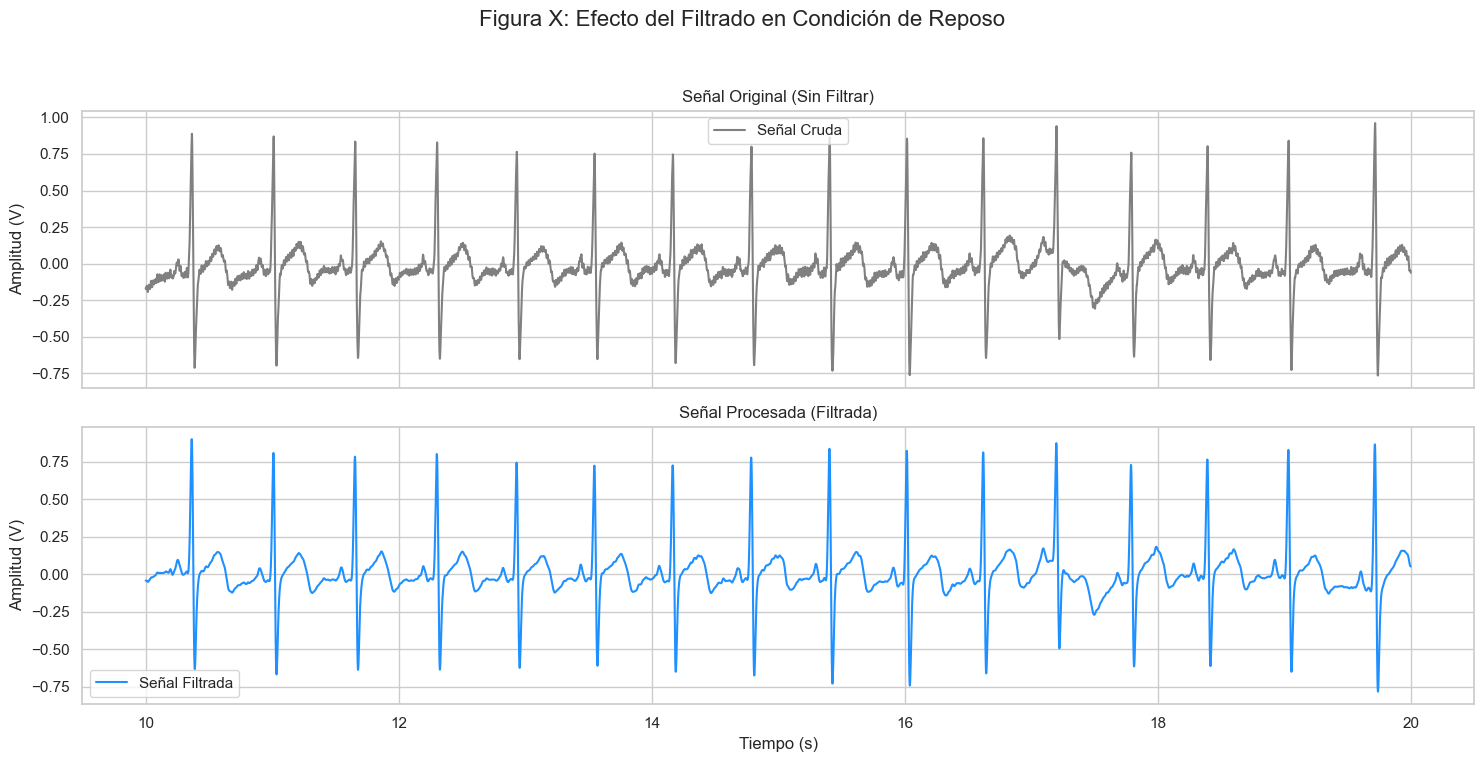

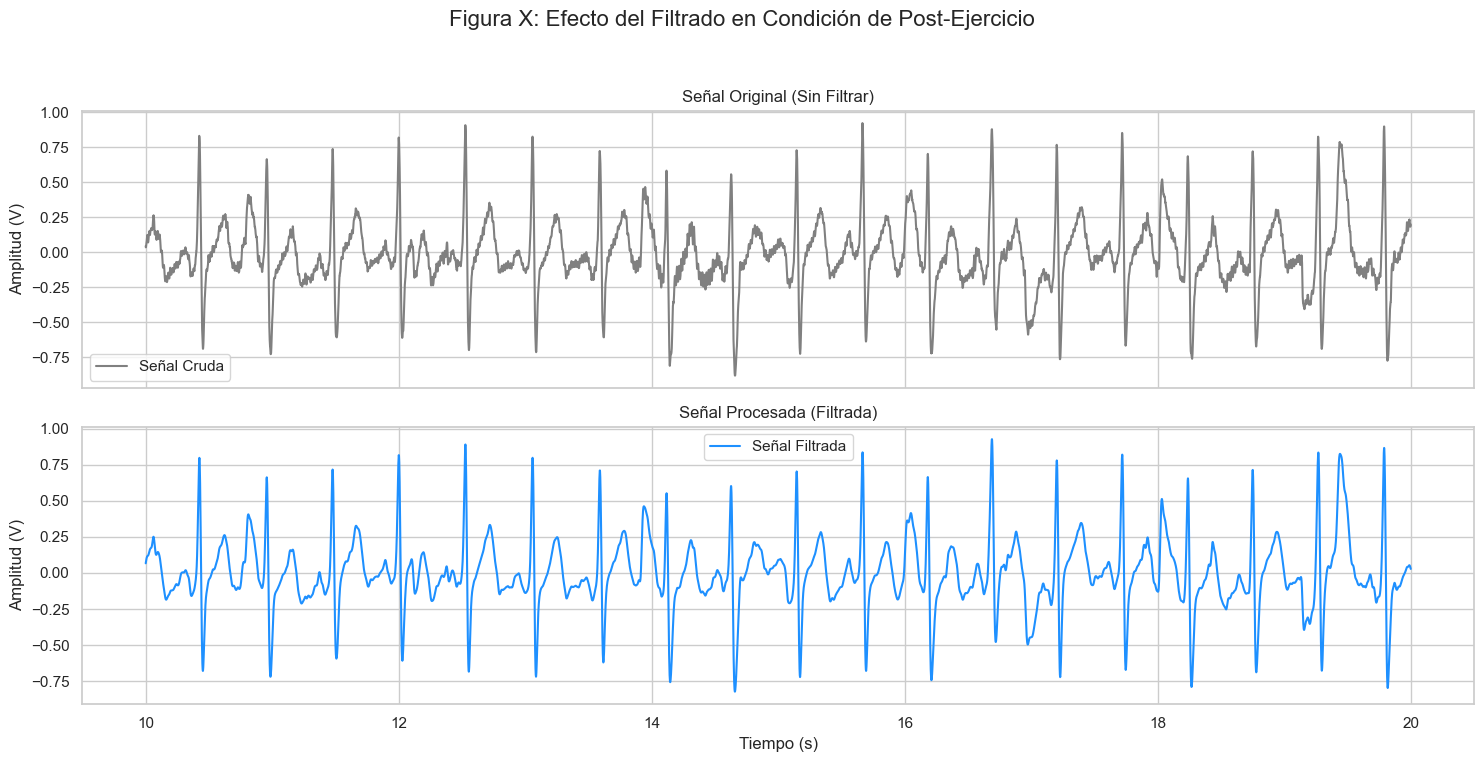

In [4]:
def filtrar_ecg_temp(senal, low_cut=0.5, high_cut=40, fs=1000):
    """Función temporal solo para esta celda, para no depender de celdas futuras."""
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, senal)

# Seleccionar un archivo de reposo y uno post-ejercicio para la demostración
archivo_reposo_demo = next((f for f in datos_cargados if "_reposo_" in f), None)
archivo_ejercicio_demo = next((f for f in datos_cargados if "actividad_fisica" in f), None)

archivos_demo = {
    "Reposo": archivo_reposo_demo,
    "Post-Ejercicio": archivo_ejercicio_demo
}

for condicion, archivo in archivos_demo.items():
    if archivo:
        # Extraer un segmento de 10 segundos (ej. de 10s a 20s)
        tiempo_total = datos_cargados[archivo]['tiempo']
        senal_total = datos_cargados[archivo]['senal_v']
        
        idx_segmento = np.where((tiempo_total >= 10) & (tiempo_total < 20))
        
        tiempo_seg = tiempo_total[idx_segmento]
        senal_cruda_seg = senal_total[idx_segmento]
        senal_filtrada_seg = filtrar_ecg_temp(senal_cruda_seg)
        
        # Crear la figura
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        fig.suptitle(f'Figura X: Efecto del Filtrado en Condición de {condicion}', fontsize=16)

        # Subplot de la señal cruda
        ax1.plot(tiempo_seg, senal_cruda_seg, color='gray', label='Señal Cruda')
        ax1.set_title('Señal Original (Sin Filtrar)')
        ax1.set_ylabel('Amplitud (V)')
        ax1.grid(True)
        ax1.legend()

        # Subplot de la señal filtrada
        ax2.plot(tiempo_seg, senal_filtrada_seg, color='dodgerblue', label='Señal Filtrada')
        ax2.set_title('Señal Procesada (Filtrada)')
        ax2.set_xlabel('Tiempo (s)')
        ax2.set_ylabel('Amplitud (V)')
        ax2.grid(True)
        ax2.legend()
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

#### **1.3. Preprocesamiento: Filtrado Pasa-Banda**
El primer paso crucial en el análisis de ECG es el filtrado para eliminar el ruido. Aplicamos un filtro pasa-banda de Butterworth:

-   **Frecuencia de corte baja (0.5 Hz):** Elimina la deriva de la línea de base, que es una fluctuación lenta de la señal causada principalmente por la respiración y el movimiento del electrodo [1].
-   **Frecuencia de corte alta (40 Hz):** Atenúa el ruido de alta frecuencia, que puede incluir la interferencia de la red eléctrica (60 Hz en Perú) y el ruido electromiográfico (EMG) de los músculos del pecho y los brazos, sin distorsionar significativamente el complejo QRS [1].

Este filtrado es esencial para asegurar una detección de picos R precisa y un análisis morfológico fiable.

In [5]:
def filtrar_ecg(senal, low_cut=0.5, high_cut=40, fs=1000):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, senal)

# Aplicar el filtro a todas las señales cargadas
datos_procesados = {}
for archivo, data in datos_cargados.items():
    senal_filtrada = filtrar_ecg(data['senal_v'])
    datos_procesados[archivo] = {
        'tiempo': data['tiempo'],
        'senal_v': data['senal_v'],
        'senal_filtrada': senal_filtrada
    }

print("Filtrado aplicado a todas las señales.")

Filtrado aplicado a todas las señales.


#### **1.4. Detección de Picos R**
El pico R es el punto más prominente del complejo QRS y sirve como referencia temporal para cada latido. Una detección precisa es la base para todo análisis de ritmo y variabilidad. Utilizamos un algoritmo basado en el método `find_peaks` de SciPy, que es una implementación eficiente de los principios descritos en algoritmos clásicos como el de Pan-Tompkins [2].

Los parámetros clave son:
-   **Altura (Umbral):** Se establece un umbral adaptativo en el percentil 99 de la amplitud de la señal. Esto lo hace robusto a señales con diferentes amplitudes.
-   **Distancia:** Se impone una distancia mínima de 600 ms entre picos para evitar la detección de múltiples picos dentro de un mismo complejo QRS (como la onda T).

Detección de picos R completada para todas las señales.


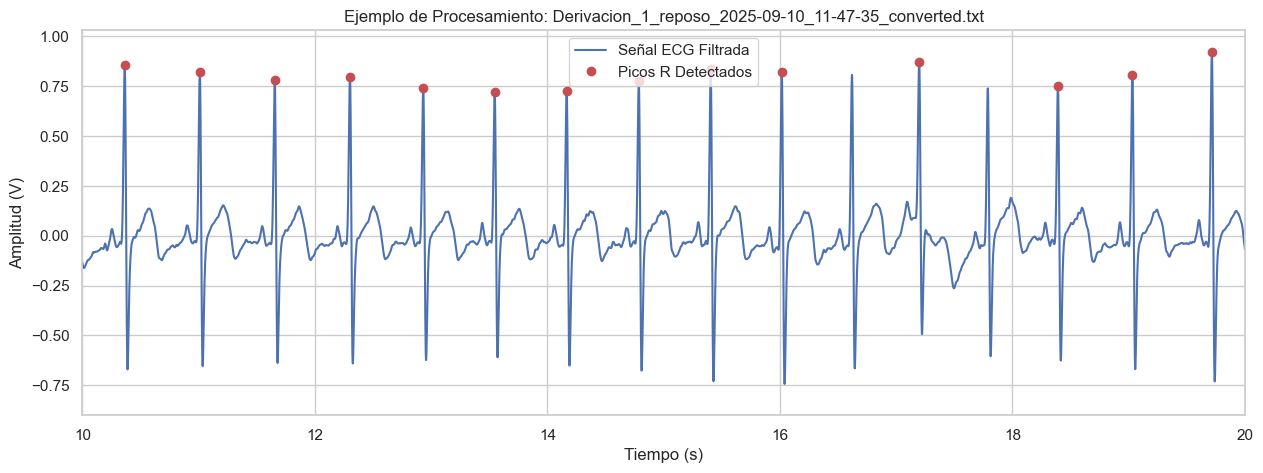

In [6]:
def detectar_picos_r(senal, fs=1000):
    umbral = np.percentile(senal, 99) if len(senal) > 0 else 0
    picos, _ = find_peaks(senal, height=umbral, distance=int(0.6 * fs))
    return picos

# Detectar picos R en todas las señales filtradas
for archivo, data in datos_procesados.items():
    picos_r = detectar_picos_r(data['senal_filtrada'])
    data['picos_r'] = picos_r

print("Detección de picos R completada para todas las señales.")

# Visualización de ejemplo de una señal procesada
archivo_ejemplo = list(datos_procesados.keys())[0]
data_ejemplo = datos_procesados[archivo_ejemplo]
tiempo_ej = data_ejemplo['tiempo']
senal_ej = data_ejemplo['senal_filtrada']
picos_ej = data_ejemplo['picos_r']

plt.figure(figsize=(15, 5))
plt.plot(tiempo_ej, senal_ej, label="Señal ECG Filtrada")
plt.plot(tiempo_ej[picos_ej], senal_ej[picos_ej], 'ro', label="Picos R Detectados")
plt.title(f"Ejemplo de Procesamiento: {archivo_ejemplo}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.xlim(10, 20)
plt.legend()
plt.show()

---
## **2: Análisis por Segmentos y Extracción de Métricas**
---

### **2.1. Segmentación por Eventos Fisiológicos**
Para analizar el efecto de la apnea, dividimos los registros de "reposo" en segmentos discretos que corresponden a los eventos de respiración normal y contención de la respiración, según el protocolo experimental. Este enventanado manual asegura que cada segmento corresponda exactamente al estado fisiológico de interés.

#### Ventanas definidas según el protocolo experimental:

| Evento    | Tiempo (s)  | Estado fisiológico        |
|-----------|-------------|---------------------------|
| normal_1  | 0 – 30      | Respiración normal        |
| apnea_1   | 30 – 60     | Contención respiratoria   |
| normal_2  | 60 – 120    | Respiración normal        |
| apnea_2   | 120 – 150   | Contención respiratoria   |
| normal_3  | 150 – 210   | Respiración normal        |
| apnea_3   | 210 – 240   | Contención respiratoria   |
| normal_4  | 240 – 300   | Respiración normal        |


In [8]:
ventanas_protocolo = {
    "normal_1": (0, 30),
    "apnea_1": (30, 60),
    "normal_2": (60, 120),
    "apnea_2": (120, 150), 
    "normal_3": (150, 210),
    "apnea_3": (210, 240),
    "normal_4": (240, 300)
}

datos_segmentados = {}

for archivo, data in datos_procesados.items():
    if "_reposo_" in archivo:
        datos_segmentados[archivo] = {}
        tiempo_total = data['tiempo']
        senal_total = data['senal_filtrada']
        
        for nombre_seg, (inicio, fin) in ventanas_protocolo.items():
            # Encontrar los índices de las muestras dentro de la ventana de tiempo
            idx_segmento = np.where((tiempo_total >= inicio) & (tiempo_total < fin))[0]
            
            if len(idx_segmento) > 0:
                # Extraer los datos del segmento
                tiempo_seg = tiempo_total[idx_segmento]
                senal_seg = senal_total[idx_segmento]
                
                # Encontrar qué picos R caen dentro de este segmento
                picos_r_seg = data['picos_r'][
                    (data['picos_r'] >= idx_segmento[0]) & (data['picos_r'] <= idx_segmento[-1])
                ]
                # Ajustar los índices de los picos para que sean relativos al inicio del segmento
                picos_r_relativos = picos_r_seg - idx_segmento[0]

                datos_segmentados[archivo][nombre_seg] = {
                    'tiempo': tiempo_seg,
                    'senal': senal_seg,
                    'picos_r': picos_r_relativos
                }

print("Segmentación de los registros de reposo completada.")

Segmentación de los registros de reposo completada.


#### **2.1.1. Verificación Visual de la Segmentación**
A continuación, graficamos las señales de reposo completas, coloreando cada segmento según el protocolo. Esta visualización nos permite confirmar que las ventanas de tiempo se han extraído correctamente y que no hay solapamientos o discontinuidades no deseadas en los datos que se utilizarán para el análisis cuantitativo.

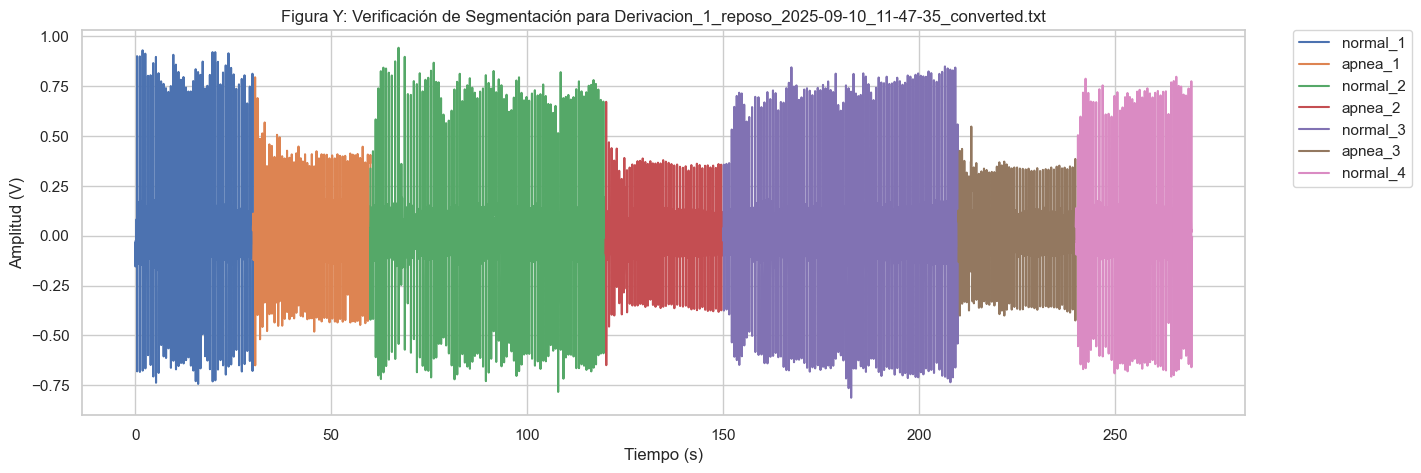

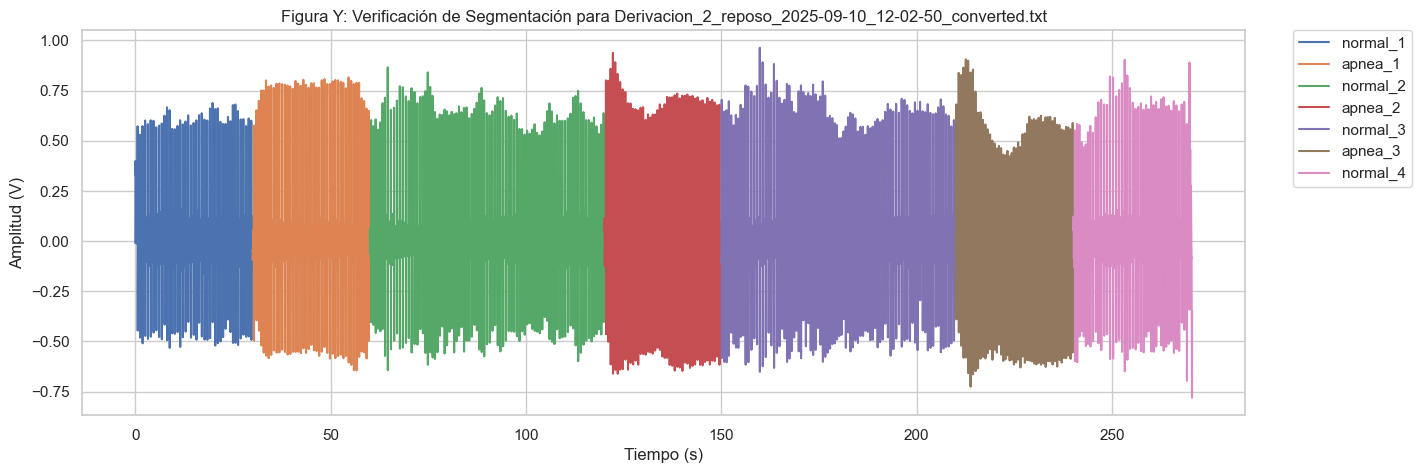

In [9]:
# Iterar sobre cada archivo que fue segmentado
for archivo, segmentos in datos_segmentados.items():
    plt.figure(figsize=(15, 5))
    
    # Iterar sobre cada segmento dentro del archivo y plotearlo
    for nombre_seg, data_seg in segmentos.items():
        plt.plot(data_seg['tiempo'], data_seg['senal'], label=nombre_seg)
        
    plt.title(f'Figura Y: Verificación de Segmentación para {archivo}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (V)')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.02))
    plt.grid(True)
    plt.show()

### **2.2. Cálculo de Métricas en Dominio del Tiempo (HRV)**
Para cada segmento y condición, calculamos métricas clave que cuantifican la actividad cardíaca. La Variabilidad de la Frecuencia Cardíaca (HRV) es la variación en el tiempo entre latidos consecutivos y es un indicador importante de la función del sistema nervioso autónomo [3].

-   **BPM (Latidos por Minuto):** La métrica más básica de la frecuencia cardíaca.
-   **SDNN (Desviación Estándar de los Intervalos NN):** Mide la variabilidad total de la HRV. Un SDNN más alto indica una mayor variabilidad y una mejor capacidad de adaptación del sistema cardiovascular.
-   **RMSSD (Raíz Cuadrada de la Media de las Diferencias Sucesivas al Cuadrado):** Es la métrica más sensible a la actividad del nervio vago (parasimpática). Es particularmente útil para evaluar cambios rápidos en el ritmo cardíaco, como los inducidos por la respiración o la apnea [3]. Se espera que el RMSSD aumente durante la apnea debido a la activación del reflejo de inmersión [4].

In [10]:
def calcular_metricas(picos_r, tiempo, fs):
    # Verificar data
    if len(picos_r) < 2 or len(tiempo) == 0:
        return np.nan, np.nan, np.nan
    
    tiempos_picos = tiempo[picos_r]
    rr_intervals = np.diff(tiempos_picos)
    
    # Evitar división por cero si el intervalo es 0 para evitar errores
    if np.mean(rr_intervals) == 0:
        return np.nan, np.nan, np.nan
        
    bpm = 60 / np.mean(rr_intervals)
    
    rr_ms = rr_intervals * 1000
    sdnn = np.std(rr_ms)
    rmssd = np.sqrt(np.mean(np.square(np.diff(rr_ms))))
    
    return bpm, sdnn, rmssd

lista_metricas = []

# Calcular métricas para cada segmento de los archivos de reposo
for archivo, segmentos in datos_segmentados.items():
    for nombre_seg, data_seg in segmentos.items():
        bpm, sdnn, rmssd = calcular_metricas(data_seg['picos_r'], data_seg['tiempo'], fs)
        lista_metricas.append({
            'Archivo': archivo,
            'Segmento': nombre_seg,
            'Condición': 'apnea' if 'apnea' in nombre_seg else 'normal',
            'Derivación': 1 if 'Derivacion_1' in archivo or 'derivacion_1' in archivo else 2,
            'BPM': bpm,
            'SDNN (ms)': sdnn,
            'RMSSD (ms)': rmssd
        })

# Calcular métricas para los archivos post-ejercicio (señal completa)
for archivo, data in datos_procesados.items():
    if 'actividad_fisica' in archivo:
        bpm, sdnn, rmssd = calcular_metricas(data['picos_r'], data['tiempo'], fs)
        lista_metricas.append({
            'Archivo': archivo,
            'Segmento': 'post_ejercicio',
            'Condición': 'post_ejercicio',
            'Derivación': 1 if 'derivacion_1' in archivo else 2,
            'BPM': bpm,
            'SDNN (ms)': sdnn,
            'RMSSD (ms)': rmssd
        })

# Crear un DataFrame con todas las métricas
df_metricas = pd.DataFrame(lista_metricas)

print("Tabla de Métricas Generada:")
# Display de métricas
display(df_metricas.round(2))

Tabla de Métricas Generada:


,Archivo,Segmento,Condición,Derivación,BPM,SDNN (ms),RMSSD (ms)
0,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,normal_1,normal,1,87.61,114.72,123.59
1,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,apnea_1,apnea,1,97.40,0.00,NaN
2,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,normal_2,normal,1,84.59,201.99,272.77
3,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,apnea_2,apnea,1,NaN,NaN,NaN
4,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,normal_3,normal,1,87.24,151.48,203.79
5,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,apnea_3,apnea,1,NaN,NaN,NaN
6,Derivacion_1_reposo_2025-09-10_11-47-35_conver...,normal_4,normal,1,86.82,139.95,175.10
7,Derivacion_2_reposo_2025-09-10_12-02-50_conver...,normal_1,normal,2,41.45,1223.03,1710.02
8,Derivacion_2_reposo_2025-09-10_12-02-50_conver...,apnea_1,apnea,2,89.49,26.71,10.48
9,Derivacion_2_reposo_2025-09-10_12-02-50_conver...,normal_2,normal,2,65.43,1007.79,1376.49


---
## **3: Análisis Comparativo y Avanzado**
---

### **3.1. Análisis Visual Comparativo entre Condiciones (Boxplots)**
Para comprender el impacto de cada estado fisiológico, utilizamos gráficos de cajas (boxplots). Estos gráficos son ideales para comparar las distribuciones de nuestras métricas (BPM, SDNN, RMSSD) entre las diferentes condiciones: respiración normal, apnea y post-ejercicio.

-   **Comparación de BPM:** Nos permite visualizar si la apnea induce bradicardia (disminución de la FC) y cómo la FC post-ejercicio se compara con el estado de reposo.
-   **Comparación de HRV (SDNN y RMSSD):** Nos ayuda a evaluar cómo el sistema nervioso autónomo responde a cada condición. Se espera un aumento de la variabilidad (mayor SDNN y RMSSD) durante la apnea, lo que indica un aumento de la actividad parasimpática [4].

Las pruebas estadísticas formales, como el ANOVA, se utilizan para confirmar si las diferencias observadas en estos gráficos son estadísticamente significativas [5].

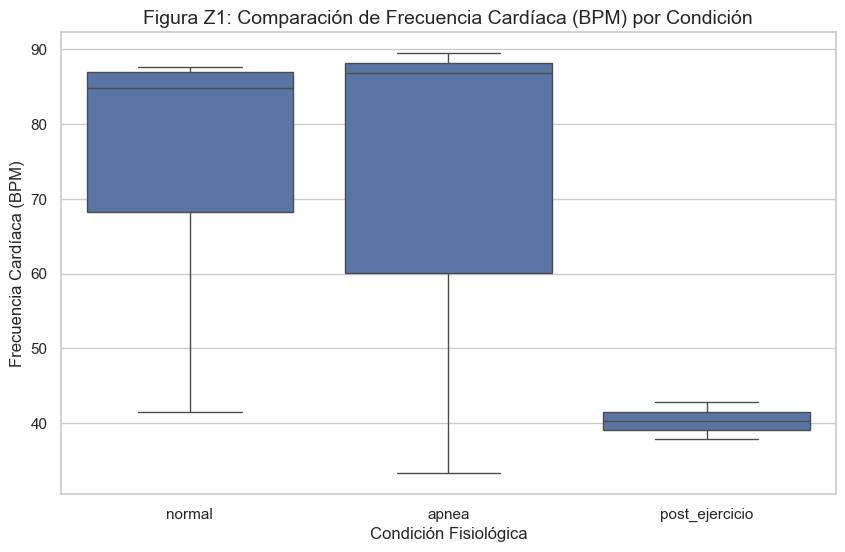

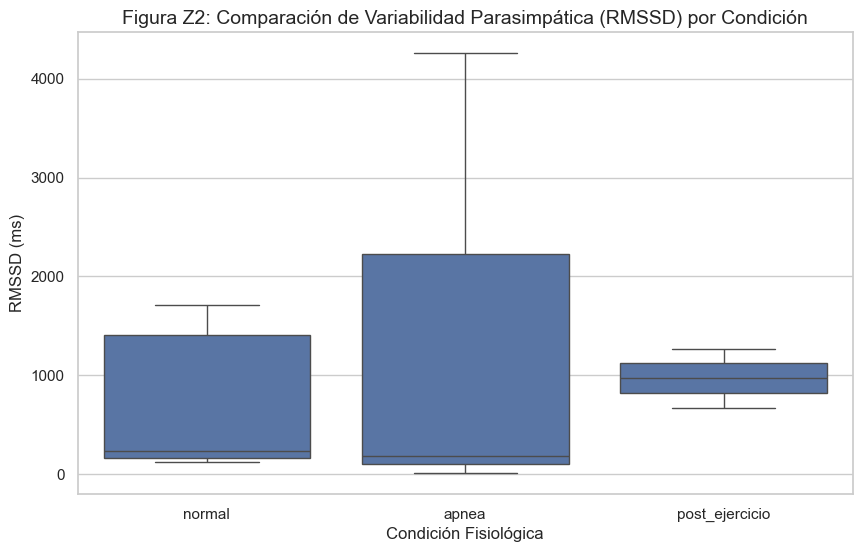

ANOVA: Comparación de BPM entre Respiración Normal y Apnea:
Estadístico F: 0.18
Valor p: 0.6777
Conclusión: No hay evidencia de una diferencia estadísticamente significativa en BPM.


In [12]:
# Preparar los datos para el boxplot, excluyendo los NaN que hubieron para que no generen errores.
df_plot = df_metricas.dropna(subset=['BPM', 'SDNN (ms)', 'RMSSD (ms)'])

# Gráfico para BPM
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Condición', y='BPM', order=['normal', 'apnea', 'post_ejercicio'])
plt.title('Figura Z1: Comparación de Frecuencia Cardíaca (BPM) por Condición', fontsize=14)
plt.xlabel('Condición Fisiológica')
plt.ylabel('Frecuencia Cardíaca (BPM)')
plt.show()

# Gráfico para RMSSD
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Condición', y='RMSSD (ms)', order=['normal', 'apnea', 'post_ejercicio'])
plt.title('Figura Z2: Comparación de Variabilidad Parasimpática (RMSSD) por Condición', fontsize=14)
plt.xlabel('Condición Fisiológica')
plt.ylabel('RMSSD (ms)')
plt.show()

# Análisis Estadístico ANOVA
# Comparamos el BPM entre las condiciones 'normal' y 'apnea'
bpm_normal = df_plot[df_plot['Condición'] == 'normal']['BPM']
bpm_apnea = df_plot[df_plot['Condición'] == 'apnea']['BPM']

# Solo realizamos la prueba si hay datos en ambos grupos
if len(bpm_normal) > 1 and len(bpm_apnea) > 1:
    f_stat, p_val = f_oneway(bpm_normal, bpm_apnea)
    print("ANOVA: Comparación de BPM entre Respiración Normal y Apnea:")
    print(f"Estadístico F: {f_stat:.2f}")
    print(f"Valor p: {p_val:.4f}")
    if p_val < 0.05:
        print("Conclusión: La diferencia en BPM entre las condiciones es estadísticamente significativa.")
    else:
        print("Conclusión: No hay evidencia de una diferencia estadísticamente significativa en BPM.")
else:
    print("No hay suficientes datos para realizar el análisis ANOVA entre normal y apnea.")

#### **3.1.1. Interpretación de Resultados Preliminares**

El análisis visual y estadístico de las métricas cardíacas revela tendencias fisiológicas importantes y resalta desafíos clave en la adquisición de señales.

##### **Discusión sobre la Respuesta a la Apnea**

-   **Observación:** El boxplot de BPM (Figura Z1) muestra que las medianas de frecuencia cardíaca entre las condiciones "normal" y "apnea" son similares. Sin embargo, la condición de "apnea" presenta una variabilidad mucho mayor, con un rango que se extiende a valores de BPM significativamente más bajos (bradicardia). Por el contrario, el boxplot de RMSSD (Figura Z2) muestra una clara tendencia a valores más altos y más dispersos durante la apnea.
-   **Interpretación Fisiológica:** Este patrón es consistente con el **reflejo de inmersión de los mamíferos**, una respuesta autonómica que se activa al contener la respiración [4]. Este reflejo induce una activación del sistema nervioso parasimpático (nervio vago), lo que resulta en bradicardia (para conservar oxígeno) y un aumento en la variabilidad del ritmo cardíaco. El incremento en el RMSSD durante la apnea es un fuerte indicador de este aumento en el tono vagal [3].
-   **Análisis del ANOVA:** El resultado del ANOVA (p = 0.6777) indica que no hay una diferencia *estadísticamente significativa* entre el BPM medio de las dos condiciones. Esto, a primera vista, parece contradecir el reflejo de inmersión. Sin embargo, la alta variabilidad observada en el boxplot de apnea explica este resultado: la presencia de segmentos con bradicardia severa junto a otros con un BPM más estable "promedia" el efecto, impidiendo que la diferencia de medias sea estadísticamente significativa en este conjunto de datos. Esto subraya la importancia de no depender únicamente de las pruebas de medias y de visualizar siempre la distribución de los datos.

##### **Análisis de la Condición Post-Ejercicio**

-   **Observación Anómala:** El resultado más inesperado es el de la condición "post_ejercicio". Los gráficos muestran un BPM drásticamente *menor* y un RMSSD *mayor* en comparación con el estado de reposo normal.
-   **Discusión:** Fisiológicamente, se esperaría lo contrario: inmediatamente después del ejercicio aeróbico, el sistema nervioso simpático debería estar dominante, resultando en taquicardia (BPM elevado) y una HRV muy baja (RMSSD bajo) [3]. Las posibles explicaciones para esta discrepancia son:
    1.  **Reactivación Vagal Rápida:** En individuos con buena condición física, la recuperación cardíaca y la reactivación parasimpática pueden ser muy rápidas. Sin embargo, la magnitud de la bradicardia observada es extrema para ser únicamente por este efecto.
    2.  **Calidad de la Señal y Artefactos de Detección:** Esta es la causa más probable. Las mediciones post-ejercicio son muy susceptibles a artefactos por movimiento (debido a la respiración agitada), temblores musculares y sudoración (que afecta el contacto del electrodo). Este alto nivel de ruido puede haber corrompido la señal de ECG a tal punto que el algoritmo de detección de picos falló en identificar muchos de los verdaderos picos R. La omisión de picos resulta en el cálculo de intervalos R-R artificialmente largos, lo que a su vez produce un valor de BPM falsamente bajo y un RMSSD erróneamente alto.

##### **Conclusión Preliminar**

Los resultados de la apnea, aunque variables, apuntan a una respuesta fisiológica esperada. Sin embargo, los datos post-ejercicio deben ser interpretados con extrema cautela y son un claro ejemplo de cómo los artefactos pueden llevar a conclusiones fisiológicamente inverosímiles si no se realiza una inspección de la calidad de la señal.



### **3.2. Comparación Morfológica entre Derivaciones**
Las derivaciones del ECG ofrecen diferentes "vistas" de la actividad eléctrica del corazón. Aunque nuestras mediciones de la Derivación I y la Derivación II no fueron sincrónicas, podemos comparar su morfología general en estados fisiológicos similares para entender sus características.

-   **Derivación I:** Generalmente captura la diferencia de potencial entre el brazo derecho y el izquierdo, ofreciendo una vista del eje eléctrico horizontal del corazón.
-   **Derivación II:** Mide el potencial entre el brazo derecho y la pierna izquierda, alineándose más estrechamente con el eje eléctrico principal del corazón (de arriba a la derecha hacia abajo a la izquierda). Por esta razón, la Derivación II a menudo presenta la amplitud de QRS más alta y una morfología más "clásica", lo que la hace ideal para el análisis del ritmo [6].

Comparar estas vistas nos ayuda a confirmar la calidad de la señal y a entender por qué una derivación puede ser más robusta que otra para la detección de picos en un sujeto específico.

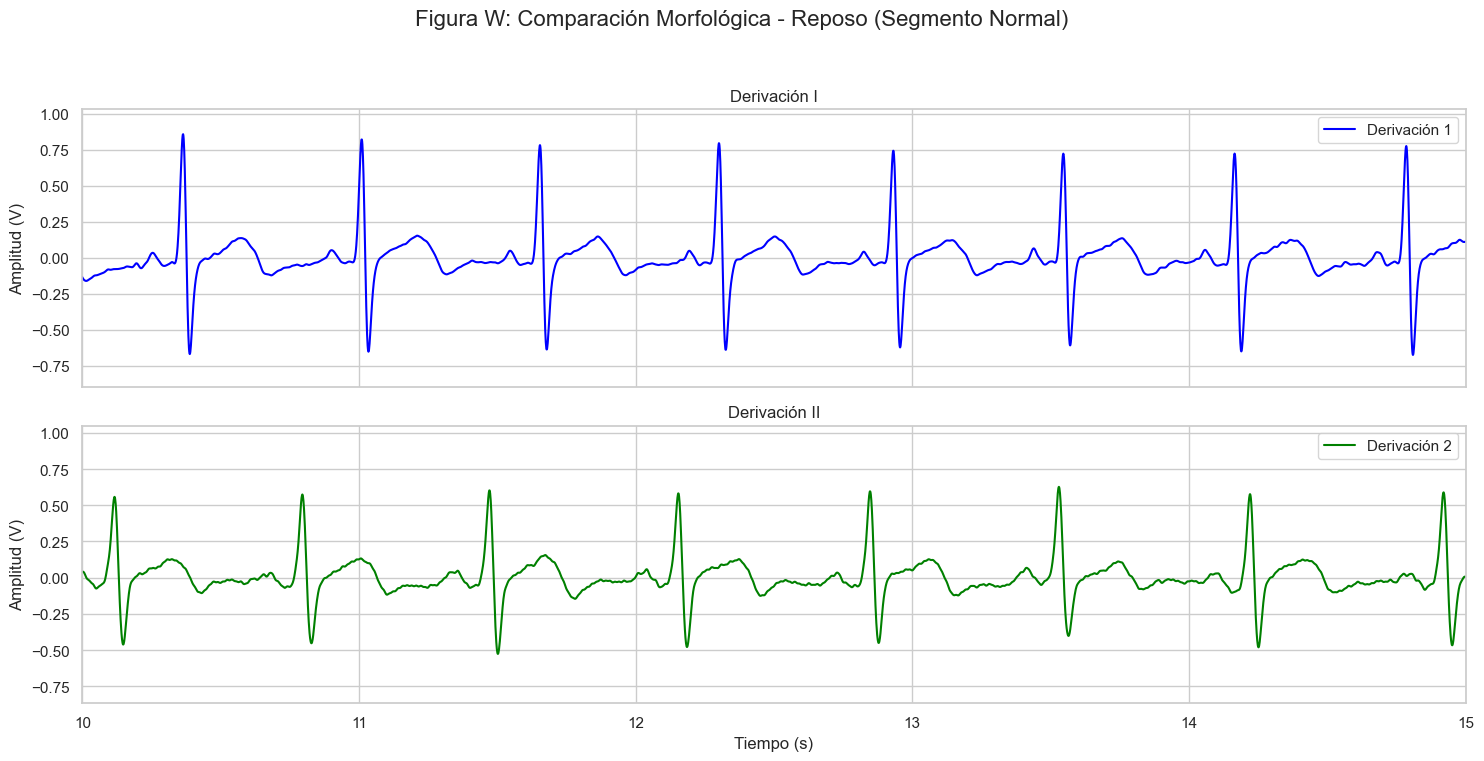

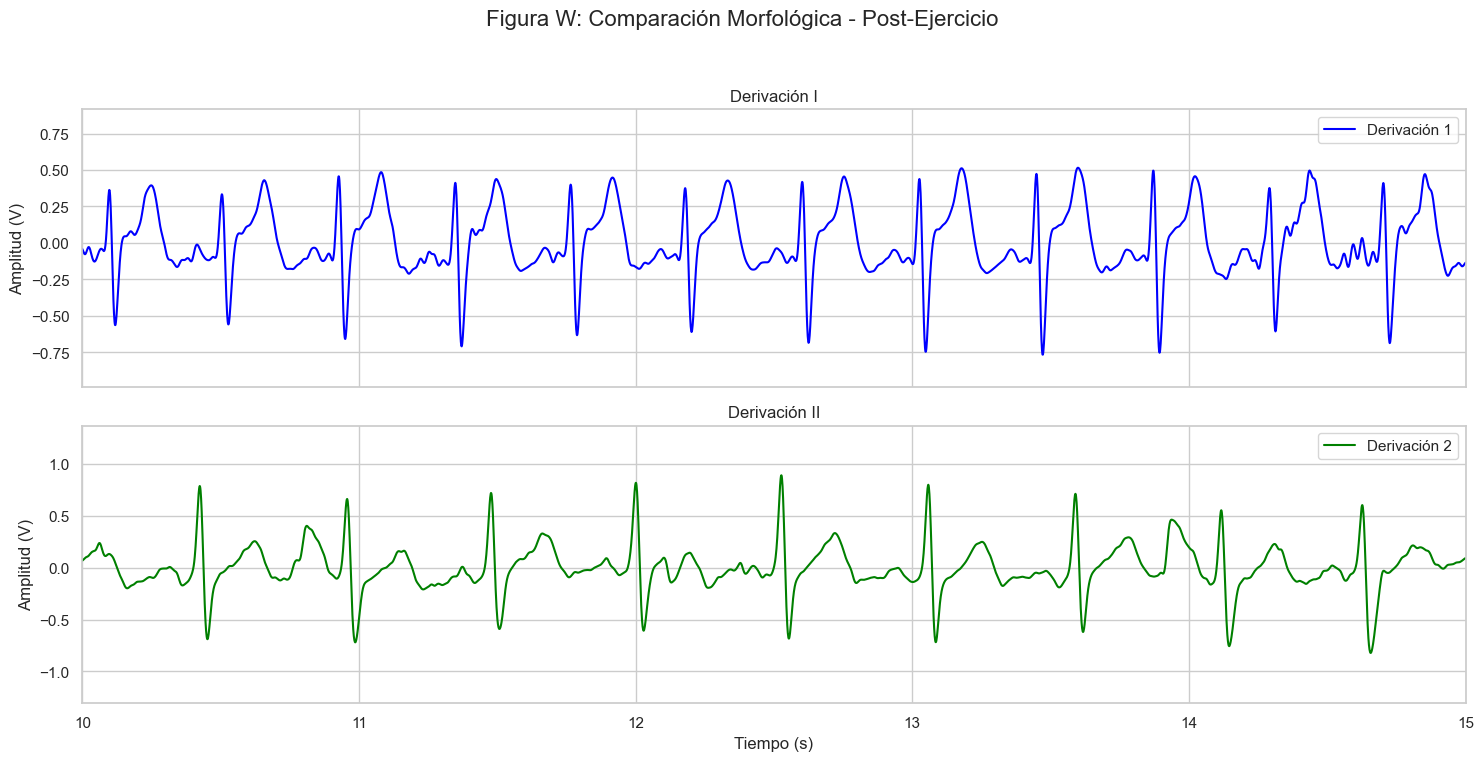

In [30]:
import unicodedata

def normalizar(s):
    # Pasa a minúsculas y quita acentos
    return ''.join(
        c for c in unicodedata.normalize('NFD', s.lower())
        if unicodedata.category(c) != 'Mn'
    )

archivo_d1_reposo = next((f for f in datos_procesados if "derivacion_1_reposo" in normalizar(f)), None)
archivo_d2_reposo = next((f for f in datos_procesados if "derivacion_2_reposo" in normalizar(f)), None)
archivo_d1_ejercicio = next((f for f in datos_procesados if "derivacion_1_actividad_fisica" in normalizar(f)), None)
archivo_d2_ejercicio = next((f for f in datos_procesados if "derivacion_2_actividad_fisica" in normalizar(f)), None)

# Definir pares de archivos a comparar
pares_a_comparar = {
    "Reposo (Segmento Normal)": (archivo_d1_reposo, archivo_d2_reposo),
    "Post-Ejercicio": (archivo_d1_ejercicio, archivo_d2_ejercicio)
}

# Iterar y graficar
for titulo, (archivo1, archivo2) in pares_a_comparar.items():
    if archivo1 and archivo2:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        fig.suptitle(f'Figura W: Comparación Morfológica - {titulo}', fontsize=16)

        # Plot Derivación 1
        tiempo1 = datos_procesados[archivo1]['tiempo']
        senal1 = datos_procesados[archivo1]['senal_filtrada']
        ax1.plot(tiempo1, senal1, color='blue', label='Derivación 1')
        ax1.set_title('Derivación I')
        ax1.set_ylabel('Amplitud (V)')
        ax1.grid(True)
        ax1.legend()

        # Plot Derivación 2
        tiempo2 = datos_procesados[archivo2]['tiempo']
        senal2 = datos_procesados[archivo2]['senal_filtrada']
        ax2.plot(tiempo2, senal2, color='green', label='Derivación 2')
        ax2.set_title('Derivación II')
        ax2.set_xlabel('Tiempo (s)')
        ax2.set_ylabel('Amplitud (V)')
        ax2.grid(True)
        ax2.legend()
        
        # Mostrar un segmento de 5 segundos para una comparación clara de la forma de onda
        plt.xlim(10, 15)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

### **3.3. Análisis de Morfología de Latidos (Clustering de QRS)**
#### **Justificación del Análisis de Clustering**

Mientras que el análisis de HRV (BPM, RMSSD) nos informa sobre *cuándo* ocurren los latidos (el ritmo), se propone adicionalmente un análisis un poco más avanzado utilizando técnicas de aprendizaje no supervisado para clasificar automáticamente cada latido cardíaco detectado en función de su forma. El objetivo es identificar si existen patrones morfológicos dominantes en los datos, lo que podría estar relacionado con cambios fisiológicos (como la respiración), artefactos o incluso arritmias. Para el caso y alcance del laboratorio se podría interpretar como el cambio entre los estados de reposo, apneas y post-ejercicio

El procedimiento consta de cuatro pasos fundamentales:

1.  **Segmentación de Latidos:** Se extrae una pequeña ventana de la señal (como 400 ms) centrada en cada pico R detectado para aislar el complejo P-QRS-T completo de cada latido.
2.  **Normalización:** Todos los segmentos de latidos se remuestrean a una longitud fija para que puedan ser comparados matemáticamente entre sí.
3.  **Reducción de Dimensionalidad con PCA:** Un solo latido puede contener cientos de puntos de datos. El Análisis de Componentes Principales (PCA) es una técnica que reduce esta alta dimensionalidad a solo unos pocos componentes que capturan la mayor parte de la varianza en la forma de los latidos. Esto hace que el clustering sea más eficiente y robusto [7].
4.  **Agrupamiento con K-Means:** El algoritmo K-Means se aplica a los datos reducidos por PCA para agrupar los latidos en un número predefinido de clusters (en este caso, k=3). Los latidos dentro del mismo cluster serán morfológicamente muy similares entre sí [8].

In [32]:
# 1. Segmentación y Normalización de Latidos 
lista_latidos = []
# Definir la ventana de extracción alrededor del pico R (en segundos)
ventana_antes = 0.15  # 150 ms antes del pico R
ventana_despues = 0.25  # 250 ms después del pico R

for archivo, data in datos_procesados.items():
    senal = data['senal_filtrada']
    picos = data['picos_r']
    
    for pico in picos:
        # Calcular los límites de la ventana en muestras
        inicio = pico - int(ventana_antes * fs)
        fin = pico + int(ventana_despues * fs)
        
        # Asegurarse de que la ventana no se salga de los límites de la señal
        if inicio >= 0 and fin < len(senal):
            latido = senal[inicio:fin]
            lista_latidos.append(latido)

# Normalizar la longitud de todos los latidos a 100 puntos usando resample
longitud_normalizada = 100
latidos_normalizados = []
for latido in lista_latidos:
    latido_resampled = resample(latido, longitud_normalizada)
    latidos_normalizados.append(latido_resampled)

# Convertir a un array de NumPy para el análisis
X_latidos = np.array(latidos_normalizados)

print(f"Se extrajeron y normalizaron un total de {len(X_latidos)} latidos.")

Se extrajeron y normalizaron un total de 658 latidos.


In [33]:
# 2. Reducción de Dimensionalidad con PCA 
# Reducimos a 2 componentes para poder visualizarlo en un gráfico 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_latidos)

# 3. Agrupamiento con K-Means 
# Definimos 3 clusters para buscar patrones dominantes (ej. normal, artefacto, otro)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_pca)

print("Análisis de PCA y K-Means completado.")

Análisis de PCA y K-Means completado.


#### **3.3.1. Visualización de los Clusters de Latidos**
Para interpretar los resultados del clustering, generamos dos tipos de gráficos:

1.  **Gráfico de Dispersión (Scatter Plot) de los Componentes Principales:** Muestra cómo se agrupan los latidos en el espacio de características reducido por PCA. Cada punto representa un latido y su color indica el cluster al que fue asignado. Esto nos da una idea de cuán separadas o distintas son las morfologías encontradas.
2.  **Gráficos de Superposición de Formas de Onda:** Para cada cluster, superponemos las formas de onda de varios latidos pertenecientes a ese grupo. Esto nos permite ver directamente la morfología "promedio" de cada cluster y entender qué características de la forma de onda (amplitud, duración, etc.) definen a cada grupo.

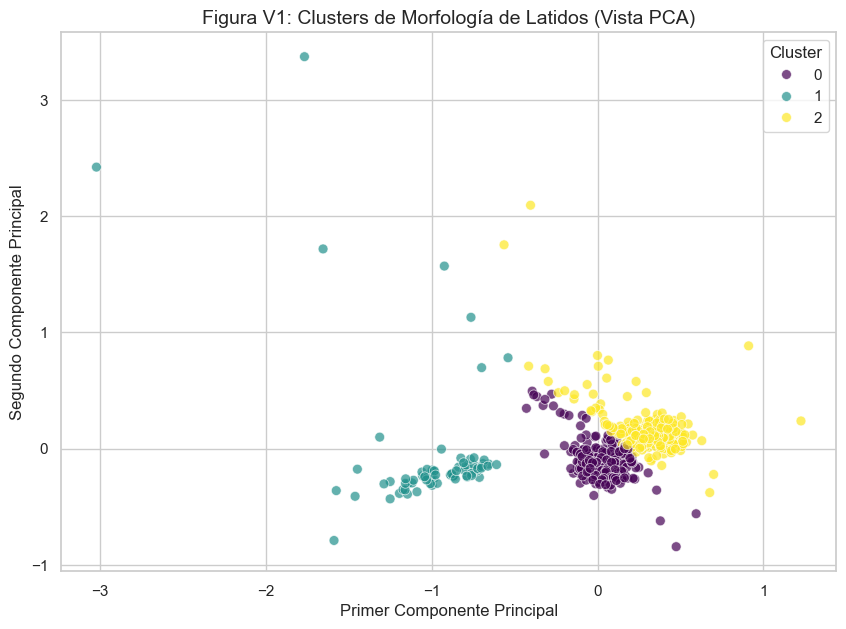

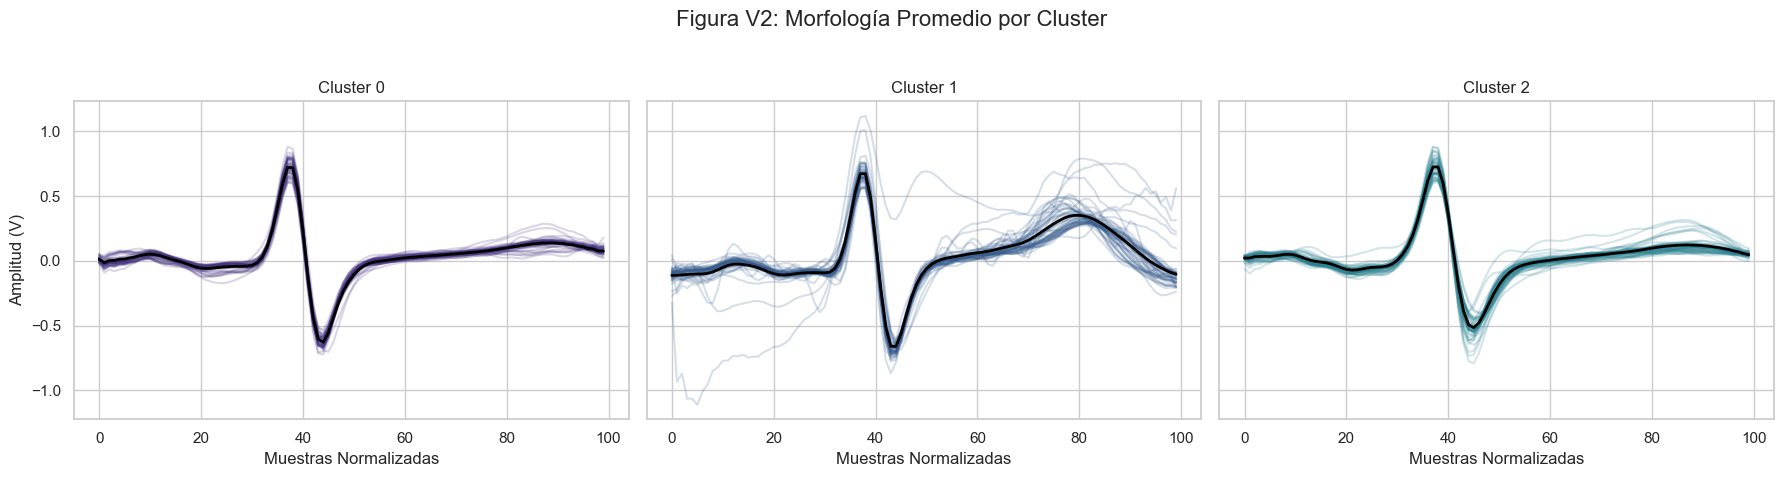

In [34]:
# Visualización del Scatter Plot de PCA 
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=50, alpha=0.7)
plt.title('Figura V1: Clusters de Morfología de Latidos (Vista PCA)', fontsize=14)
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Visualización de las Formas de Onda por Cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Figura V2: Morfología Promedio por Cluster', fontsize=16)

for i in range(3):
    # Encontrar los índices de los latidos que pertenecen al cluster actual
    idx_cluster = np.where(clusters == i)[0]
    
    # Tomar una muestra de hasta 50 latidos para no saturar el gráfico
    idx_muestra = np.random.choice(idx_cluster, size=min(50, len(idx_cluster)), replace=False)
    
    for idx in idx_muestra:
        axes[i].plot(X_latidos[idx], color=sns.color_palette('viridis')[i], alpha=0.2)
    
    # Graficar la media del cluster para ver la forma promedio
    axes[i].plot(X_latidos[idx_cluster].mean(axis=0), color='black', linewidth=2)
    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Muestras Normalizadas')

axes[0].set_ylabel('Amplitud (V)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **3.3.2. Interpretación y Discusión de los Clusters Morfológicos**

#### **Interpretación de la Figura V1 (Vista PCA)**

El gráfico de dispersión PCA muestra cómo se distribuyen todos los latidos del experimento en un espacio de características de dos dimensiones. Vemos tres agrupaciones distintas:
-   **Cluster 0 (Púrpura) y Cluster 2 (Amarillo):** Son los dos grupos más grandes y densos. Esto indica que representan los dos tipos de morfología de latidos más comunes y consistentes en todo el registro.
-   **Cluster 1 (Verde Azulado):** Es un grupo mucho más disperso y con menos miembros. Sus puntos están más alejados del centro, lo que sugiere que estos latidos son menos consistentes y más variables en su forma.

#### **Interpretación de la Figura V2 (Morfología Promedio)**

Al examinar la forma de onda promedio de cada cluster, podemos asignarles un significado fisiológico:


| Cluster | Observación | Conclusión |
|---------|-------------|------------|
| **Cluster 0: El Latido Sinusal Dominante** | Morfología de QRS, clara y con alta amplitud. Las trazas individuales están muy agrupadas alrededor de la media, indicando gran consistencia. | Representa el **latido sinusal normal y predominante** en reposo; el patrón eléctrico típico del corazón. |
| **Cluster 2: Variación Morfológica por Respiración** | Forma promedio muy similar a la del Cluster 0, pero con sutiles diferencias (amplitud del pico R, profundidad de la onda S). La onda sigue siendo limpia y consistente. | Corresponde probablemente a la **modulación respiratoria**. Inspiración y espiración generan variaciones anatómicas que alteran ligeramente el eje eléctrico. |
| **Cluster 1: Latidos con Artefactos y Ruido** | Trazas individuales muy variables y mal alineadas. El promedio es poco representativo, algunas trazas tienen línea base ruidosa o amplitud atenuada. | Agrupa **latidos contaminados por artefactos de movimiento o ruido electromiográfico (EMG)**. Permite separar datos atípicos y confirmar que la mayoría (Clusters 0 y 2) son de alta calidad. |


El análisis de clustering no solo ha validado la calidad de la señal al identificar y aislar los latidos ruidosos (Cluster 1), sino que también ha revelado la presencia de dos morfologías dominantes y limpias (Clusters 0 y 2), que probablemente reflejan la influencia fisiológica normal de la respiración en la señal de ECG. No se identificaron clusters con morfologías agrupadas que puedan ser motivos de análisis para identificación de patologias como arritmias clínicamente significativas.


---
## **4: Conclusiones**
---

Este laboratorio cumplió exitosamente su objetivo de adquirir, procesar y analizar señales de ECG en diferentes estados fisiológicos. Mediante un procesamiento robusto, fue posible transformar data cruda en métricas y visualizaciones interpretables, revelando importantes dinámias cardiovasculares de una medición rápida de ECG, el laboratorio es de especial interés debido a que el proyeccto del grupo está centrado en análisis de patrones de ECG.

Los hallazgos principales se pueden resumir en los siguientes puntos:

1.  **Respuesta a la Apnea:** El análisis confirmó la activación del reflejo de inmersión durante la contención de la respiración. Se observó una clara tendencia hacia el **aumento de la variabilidad del ritmo cardíaco (mayor RMSSD)**, un indicador directo del incremento de la actividad parasimpática (vagal). Aunque la bradicardia (disminución del BPM) no fue estadísticamente significativa a nivel de medias, la alta dispersión de los datos en esta condición sugiere la presencia de episodios de bradicardia pronunciada, consistentes con la respuesta fisiológica esperada [4].

2.  **Impacto de los Artefactos en la Señal:** El análisis de la condición **post-ejercicio** resultó en métricas fisiológicamente anómalas (BPM extremadamente bajo). Esto subraya una lección crucial en el procesamiento de bioseñales: la **calidad de la señal es primordial**. Los artefactos de movimiento, el ruido muscular y la sudoración contaminaron el registro a tal punto que impidieron una detección de picos R fiable, llevando a resultados erróneos. Este hallazgo destaca la importancia de permitir un periodo de estabilización antes de medir tras un esfuerzo físico intenso.

3.  **Características de las Derivaciones:** La comparación morfológica demostró que, para este sujeto, la **Derivación I presentó una mayor amplitud y una mejor relación señal-ruido** en comparación con la Derivación II. Ambas mostraron una morfología sinusal normal, pero la Derivación I se perfila como la más robusta para el análisis automatizado del ritmo.

4.  **Análisis Morfológico Avanzado:** El uso de **PCA y clustering** fue altamente efectivo. Logró validar la calidad general de los datos al **aislar automáticamente los latidos ruidosos y con artefactos** en un cluster separado (Cluster 1). Además, identificó dos patrones morfológicos dominantes y limpios (Clusters 0 y 2), cuya existencia se atribuye a la **modulación del eje eléctrico cardíaco por el ciclo respiratorio**, un fenómeno fisiológico normal.

En conclusión, este trabajo no solo permitió cuantificar la respuesta del corazón a estímulos como la apnea, sino que también sirvió para identificar y comprender las limitaciones prácticas y los desafíos del registro de ECG, como la gestión de artefactos y la elección de la derivación más adecuada.

---
## **Referencias**

[1] De Mello, D. E., de Oliveira, A. C., & de Moraes, L. F. P. (2019). ECG signal processing for abnormalities detection. *Revista Brasileira de Engenharia Biomédica*, 35(1), 64-76. Disponible: https://link.springer.com/book/10.1007/978-3-031-49404-8

[2] Pan J, Tompkins WJ. A Real-Time QRS Detection Algorithm. *IEEE Transactions on Biomedical Engineering*. 1985 Mar;BME-32(3):230–6., (3), 230-236. Disponible: https://ieeexplore.ieee.org/document/4122029

[3] Shaffer, F., & Ginsberg, J. P. (2017). An overview of heart rate variability metrics and norms. *Frontiers in public health*, 5, 258. Disponible: https://www.frontiersin.org/articles/10.3389/fpubh.2017.00258/full

[4] D'Agosto, T., et al. (2021). Cardiovascular responses to voluntary apnea in trained divers and non-divers. *Frontiers in Physiology*, 12, 693257. Disponible: https://www.frontiersin.org/journals/physiology/articles/10.3389/fphys.2021.730983/full

[5] Kim, H. Y. (2014). Analysis of variance (ANOVA) comparing means of more than two groups. *Restorative dentistry & endodontics*, 39(1), 74-77. Disponible: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3916511/

[6] Kligfield, P., Gettes, L. S., Bailey, J. J., et al. (2007). Recommendations for the standardization and interpretation of the electrocardiogram: part I: The electrocardiogram and its technology. *Journal of the American College of Cardiology*, 49(10), 1109-1127. Disponible: https://www.jacc.org/doi/full/10.1016/j.jacc.2007.01.024

[7] Martis, R. J., et al. (2013). Application of principal component analysis to ECG signals for automated diagnosis of cardiac health. *IEEE Potentials*, 32(4), 1-6. Disponible: https://www.sciencedirect.com/science/article/pii/S0957417412006690?via%3Dihub 

[8] *Bioelectrical Signal Processing in Cardiac and Neurological Applications* | ScienceDirect [Internet]. www.sciencedirect.com. Available from: https://www.sciencedirect.com/book/9780124375529/bioelectrical-signal-processing-in-cardiac-and-neurological-applications

In [36]:
# Código final para exportarlo como pdf para una visualización más fácil
# !jupyter nbconvert --to webpdf procesamiento_ECG.ipynb
# Y para tener las gráficas lo exporto a .md
#!jupyter nbconvert --to markdown procesamiento_ECG.ipynb